## `I. Transfer learning (en vision)`
- Utilisation d'un réseau de neurones convolutif (ConvNet) comme extracteur de caractéristiques fixes. 
- Prendre un ConvNet pré-entraîné sur ImageNet, 
- Supprimer la dernière couche entièrement connectée 
- Les sorties correspondent aux scores des 1 000 classes pour une tâche différente, comme ImageNet, 
- Traiter le reste du ConvNet comme un extracteur de caractéristiques fixes pour le nouveau jeu de données.
:::
__L’apprentissage par transfert (transfer learning) consiste à :__ 
 - réutiliser un modèle déjà entraîné sur une première tâche 
 - pour en apprendre une nouvelle, proche, au lieu de repartir de zéro.
__Apprentissage par transfert d'un réseau de neurones convolutif pour la classification d'images.__
- Modifié de https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html 
__Pour en savoir plus, en particulier sur des critères permettant de choisir l'une ou l'autre approche.__ 
 - voir par exemple https://cs231n.github.io/transfer-learning/
:::

:::
### _`1.1 Idée de base`_
__Un modèle a appris à classifier représentations sur une tâche de type ImageNet / ConvNet__ 
__Le but est d'adapter ce modèle à une tâche B liée__
- par ex. classifier des types de tumeurs, des pièces mécaniques, des races de chiens avec peu de données.
- On _transfère_ les connaissances de A vers B en réutilisant ce que le modèle sait sur un nouveau problème.
- Cette ré-utilisation permet de réduire le temps et le coût d’entraînement en deep learning.
- Cela permet également de mieux généraliser quand on a peu de données pour la tâche cible.
:::
:::
### _`1.2 Principaux scénarios d'apprentissage par transfert` :_
__Fine-tuning du réseau__ 
- Plutot qu'une initialisation aléatoire, on repart du modèle pré‑entraîné 
- on continue d’entraîner tout ou partie des couches sur la nouvelle base de données, 
- souvent avec un faible learning rate. 
__Feature extraction :__ 
- Dans ce cas, on conserve le backbone pré‑entraîné (par ex. ConvNeXt sur ImageNet), 
- nous gelons les poids pour tout le réseau on fige ses poids, 
- à l'exception de la dernière couche entièrement connectée, responsable de la classification
- cette couche entièrement connectée est remplacée par une nouvelle couche avec des poids aléatoires 
- cette seule couche de sortie adaptée à la nouvelle tâche est entraînée 
__Domain adaptation / transfert transductif :__ 
- même tâche mais distribution de données différente 
- par ex. mêmes classes objet, mais images prises dans un autre domaine : médical, industriel, etc..
:::
:::
### _`1.3 Quand et comment effectuer un réglage fin`_
__1. Le nouveau jeu de données est petit et similaire au jeu de données original__
- Il est déconseillé d'affiner le réseau de neurones convolutif (ConvNet) afin d'éviter le surapprentissage.
__2. Le nouveau jeu de données est volumineux et similaire au jeu de données original__
- Disposant de davantage de données, nous pouvons être plus confiants quant au risque de surapprentissage.
__3. Le nouveau jeu de données est petit mais très différent du jeu de données original__
- Vue la petite taille, il est préférable d'entraîner uniquement un classificateur linéaire.
- Entraîner le classificateur SVM à partir des activations situées plus tôt dans le réseau.
__4. Le nouveau jeu de données est volumineux et très différent du jeu de données original__
- On pourrait s'attendre à entraîner un réseau de neurones convolutif (ConvNet) à partir de zéro.
- Il est souvent plus avantageux d'initialiser les poids avec ceux d'un modèle pré-entraîné.
:::

In [13]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torch.backends.mps as mps
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

print(mps.is_available())
plt.ion()   # interactive mode

True


### _`II. API moderne`_
:::
__Basée sur une énumération ConvNeXt_Tiny_Weights `ConvNeXt_Tiny_Weights.DEFAULT`__
- Pointe vers le jeu de poids recommandé (actuellement _IMAGENET1K_V1_), 
- Si les auteurs changent le « meilleur » checkpoint, le code suivra automatiquement.
- Contient des méta‑données (transforms recommandées, catégories, etc.), utiles pour préparer les images.
:::

In [ ]:
# manière 1 :
# C’est l’ancienne interface de torchvision, maintenue pour compatibilité, 
# mais considérée comme « legacy ». 
# model = convnext_tiny(weights="IMAGENET1K_V1")

In [4]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
# manière 2 : 
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

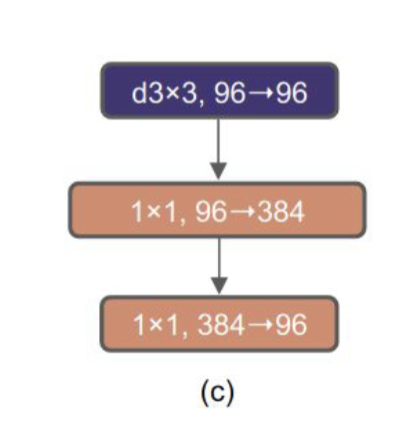

In [6]:
path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_CNN_Modernes/images"
filename="macroDesign.png"
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=200))

#### _`Rappel :`_
_model.eval()_ 
 - Désactive dropout, 
 - Met batchnorm en mode inférence, etc., 
 - Indispensable pour l’inférence.
 - Requis pour pré-traitement, 
   - mettre au format « recommandé par les weights » 
   - les transforms inclus dans ConvNeXt_Tiny_Weights

In [11]:
# Set model to eval mode
model.eval()
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

#### _`2.1 stages hiérarchiques pour ConvNeXt‑T`_
Pour ConvNeXt‑Tiny, hidden_sizes = [96, 192, 384, 768] → largeur (nb de canaux / filtres) des 4 stages.

| _`Stage`_ | _`Résolution typique`_ | _`Canaux C`_ | _`Blocs B`_ |
|-------|--------------------|----------|---------|
| 1     | 56×56              | 96       | 3       |
| 2     | 28×28              | 192      | 3       |
| 3     | 14×14              | 384      | 9       |
| 4     | 7×7                | 768      | 3       |

__Pour le stem Conv2d(3, 96, kernel_size=4, stride=4)__
- L’image d’entrée a 3 canaux (R, G, B).
- La couche possède 96 filtres, chacun de taille 3×4×4 (un petit cube qui couvre les 3 canaux sur un patch 4×4).
 - Chaque filtre balaye toute l’image, et produit une feature map 2D en sortie.
__Donc au total :__
- les 96 filtres effectuent chacun une convolution sur les 3 canaux de l’image (en combinant R, G, B dans un même filtre),
- ce qui donne 96 feature maps, soit une sortie de forme (batch, 96, 56, 56) pour une image (batch, 3, 224, 224)

#### `2.2. Macro‑architecture (stages et dimensions)`
ConvNeXt garde une structure ResNet‑like en 4 stages, avec downsampling entre eux.


:::
_`Input / Stem`_
- En vision (CNN modernes), le stem est le bloc d’entrées du réseau.
- Convolution 4×4, stride 4, réduit l’image 224×224→56×56 et passe de 3 à 1 canal (96 pour ConvNeXt‑T).
_`Équivaut à un “patch embedding” façon ViT`_
__ViT Vision Transformer__ 
- C'est une architecture qui applique le principe des Transformers 
- Self‑attention, MLP, LayerNorm… à des images, 
- En remplaçant la séquence de mots par une séquence de patchs d’image.
__Patch embedding__ 
- On découpe l’image en patchs non chevauchants (par ex. 16×16).
- Chaque patch est aplati (tous ses pixels) puis projeté linéairement dans un vecteur de dimension D 
- C’est un token d’entrée du Transformer (comme un mot encodé).
- La conv 4×4 stride 4 de ConvNeXt fait presque la même chose :
  - stride 4 → patchs 4×4, non chevauchants ;
  - 3 canaux → 96 canaux = vecteur de dimension 96 par patch ;
  - la grille 56×56 est exactement une carte de patchs, 
  - que l'on peut interpréter comme une séquence de 56×56 tokens.

:::
__`Downsampling entre stages :`__ 
- 3 couches de downsampling séparées, 
- chacune est une conv 2×2, stride 2, 
- qui divise la résolution par 2 et double les canaux $C_i → C_{i+1}$
__`Head de classification :`__ 
- LayerNorm sur les features finaux, 
- global average pooling (ou global mean sur les dimensions spatiales), 
- puis Linear vers les classes.
:::


### __`Bloc ConvNeXt (la brique de base)`__
:::
__`1. Entrée et premiers patchs`__
(0): Conv2dNormActivation(
   - (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
   - (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True))

`Convolution 4×4 stride 4` : convertit l’image (3 canaux) en 96 cartes de caractéristiques, en découpant implicitement l’image en « patchs » 4×4 (comme un patch embedding de ViT).

`LayerNorm2d` applique une normalisation par couche sur les 96 canaux, ce qui stabilise l’optimisation et remplace le duo BatchNorm + ReLU des ResNet classiques.
:::
:::
__`2. Blocs ConvNeXt (CNBlock)`__  
CNBlock( (block): Sequential(
 - (0): Conv2d(C, C, kernel_size=7, padding=3, groups=C)   # depthwise
 - (1): Permute()
 - (2): LayerNorm((C,), ...)
 - (3): Linear(C, 4C)                                      # MLP expansion
 - (4): GELU()
 - (5): Linear(4C, C)                                      # MLP projection
 - (6): Permute() )
  (stochastic_depth): StochasticDepth(p=..., mode=row))

`Conv2d(... groups=C)` : 
 - convolution depthwise 7×7 par canal (comme une attention locale large, mais purement conv).
 - pour chaque canal, un filtre 7×7 « regarde autour » de chaque pixel et combine ses voisins.
 - Avec un kernel 7×7, la valeur de sortie en (h,w) est une combinaison linéaire des 49 pixels.
 - l’information devient plus lissée et contextuelle spatialement.
   - peut apprendre un effet de flou / lissage proche d’un filtre gaussien.
   - peut au contraire apprendre un détecteur de contours (Sobel‑like, Laplacien, etc.).
   - peut capter des textures ou motifs plus larges rayures, taches, motifs répétitifs,.. 
`Permute()` : 
 - passe du format N,C,H,W à N,H,W,C pour appliquer LayerNorm 
 - et les Linear comme dans un transformer (norme sur la dimension canaux).
`MLP` : 
 - Linear(C → 4C), GELU, Linear(4C → C)
    - exactement le bloc feed‑forward d’un transformer, 
    - appliqué point par point sur chaque position spatiale.
`StochasticDepth` : 
 - drop de chemin résiduel aléatoirement (skip connection « éteint » avec proba p) pour régulariser en profondeur. 
 - La probabilité augmente avec la profondeur (0 → 0.1).

Implicitement, chaque CNBlock a aussi un résidu du type x + drop(block(x)) même s’il n’apparaît pas dans le print
:::
:::
__`3. Les 4 « stages » hiérarchiques`__
On a une structure en 4 niveaux, comme un ResNet, avec downsampling entre les niveaux.
__1. Stage 1 (C = 96)__ 
- (1): Sequential( 3 × CNBlock avec C=96, p_sd croissant 0 → 0.0117 )
- Résolution encore élevée, peu de canaux, 3 blocs.
__2. Downsampling 1 → 2__
(2): Sequential(
 - (0): LayerNorm2d(96)
 - (1): Conv2d(96, 192, kernel_size=2, stride=2)).   
 - _Norme puis conv 2×2 stride 2 :_ réduit H,W de 2, double les canaux (96 → 192)
__3. Stage 2 (C = 192)__
(3): Sequential( 3 × CNBlock avec C=192, p_sd ≈ 0.0176 → 0.0294 )
__4. Downsampling 2 → 3__
(4): Sequential(
  - (0): LayerNorm2d(192)
  - (1): Conv2d(192, 384, kernel_size=2, stride=2))
__5. Stage 3 (C = 384)__
(5): Sequential( 9 × CNBlock avec C=384, p_sd ≈ 0.035 → 0.082 )
:::




On récupère en une ligne les transformations faites sur les images spécifiques à ce modèle et qu'il faut appliquer à toute image nouvelle à tester :  

In [ ]:
preprocess = weights.transforms()

D'après la doc, cela correspond à : 

https://pytorch.org/vision/main/models/generated/torchvision.models.convnext_tiny.html#torchvision.models.convnext_tiny

"preprocessing operations: Accepts PIL.Image, batched (B, C, H, W) and single (C, H, W) image torch.Tensor objects. The images are resized to resize_size=[236] using interpolation=InterpolationMode.BILINEAR, followed by a central crop of crop_size=[224]. Finally the values are first rescaled to [0.0, 1.0] and then normalized using mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225].
"

## Charger les données

Nous utiliserons torchvision et torch.utils.data pour charger les données.

Le problème que nous allons résoudre aujourd'hui est d'entrainer un modèle pour classifier **fourmis** et **abeilles**. 

Nous disposons d'environ 120 images d'entraînement pour les fourmis et les abeilles. Il y a 75 images de validation pour chaque classe. 

Ce jeu de données (issu d'ImageNet) est très petit pour entraîner un réseau profond à partir de zéro. Puisque nous utilisons l'apprentissage par transfert, nous devrions pouvoir généraliser raisonnablement bien.


In [ ]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip

In [ ]:
!unzip -q hymenoptera_data.zip

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True

In [ ]:
data_dir = 'hymenoptera_data'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          preprocess)
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(dataset_sizes)
class_names = image_datasets['train'].classes
print(class_names)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = model.to(device)

Visualisation

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

Testons le modèle

In [ ]:
def visualize_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    # fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            max_values, preds = torch.max(outputs, 1)

            # break
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                category_name = weights.meta["categories"][preds[j]]
                # print(f"{category_name}: {100 * torch.sigmoid(max_values[j]).item():.1f}%")
                ax.set_title(f'predicted: {category_name} {100 * torch.sigmoid(max_values[j]).item():.1f}%')
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [ ]:
visualize_predictions(model, num_images=4)

On voit que les prédictions sont presque toujours exactes... Sauf que le modèle prédit 1000 classes, donc parfois "nid d'abeilles" ("honeycomb") au lieu d'abeille tout court...

# Une fonction de train générique

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Visualiser des prédictions sur deux classes

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Apprentissage par transfert 1 : finetuning

In [ ]:
model_ft = model

# récupérer la dimension des inputs à la couche de classification de ConvNeXt : 
num_ftrs = ???
print(num_ftrs)
# remplacer la couche linéaire du classifieur par un nouvelle couche à deux neurones de sortie : 
model_ft ??

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Tous les poids vont être optimisés ici : 
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Diminuer LR d'un facteur 0.1 chaque 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=3)

In [ ]:
visualize_model(model_ft)

# Apprentissage par transfert 2 : extraction de features puis classifieur

In [ ]:
model_extract = model
# récupérer la dimension des inputs à la couche de classification de ConvNeXt : 
num_ftrs = ???
print(num_ftrs)

# "geler" les poids de model_extract : 
??

# remplacer la couche linéaire du classifieur par un nouvelle couche à deux neurones de sortie : 
model_ft ??

model_extract = model_extract.to(device)

criterion = nn.CrossEntropyLoss()

# Tous les poids vont être optimisés ici : 
optimizer_ft = optim.SGD(model_extract.parameters(), lr=0.001, momentum=0.9)

# Diminuer LR d'un facteur 0.1 chaque 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model_extract, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=3)

In [ ]:
visualize_model(model_ft)